## Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical


## Load CIfar 10

In [ ]:
# Load CIFAR-10
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
x_train_full = x_train_full / 255.0
x_test = x_test / 255.0

# Subset of 2000 training images
subset_size = 2000
x_train = x_train_full[:subset_size]
y_train = y_train_full[:subset_size]

# Use 20% of subset for validation
val_split = int(0.2 * subset_size)
x_val = x_train[:val_split]
y_val = y_train[:val_split]
x_train = x_train[val_split:]
y_train = y_train[val_split:]

# One-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_val_cat = to_categorical(y_val, 10)
y_test_cat = to_categorical(y_test, 10)

print("Train:", x_train.shape, "Val:", x_val.shape, "Test:", x_test.shape)


Train: (1600, 32, 32, 3) Val: (400, 32, 32, 3) Test: (10000, 32, 32, 3)


## Pretrained MobileNetv2

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.models import Model

def build_model(img_size=96, train_base=False):
    base_model = MobileNetV2(include_top=False, input_shape=(img_size, img_size, 3), weights='imagenet')
    base_model.trainable = train_base  # Set to True only during fine-tuning

    inputs = Input(shape=(img_size, img_size, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(10, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
# Unfreeze last 30 layers of base model for fine-tuning
model = build_model() # Build the model first
model.layers[1].trainable = True  # base_model is the 2nd layer
for layer in model.layers[1].layers[:-30]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
x_train_resized = tf.image.resize(x_train, (96, 96))
x_val_resized = tf.image.resize(x_val, (96, 96))

## Train without Augmentation

In [ ]:
model_no_aug = build_model()
history_no_aug = model_no_aug.fit(
    x_train_resized, y_train_cat,
    epochs=20,
    validation_data=(x_val_resized, y_val_cat),
    batch_size=32,
    verbose=1
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - accuracy: 0.2544 - loss: 2.3886 - val_accuracy: 0.5800 - val_loss: 1.1899
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6190 - loss: 1.1456 - val_accuracy: 0.6425 - val_loss: 0.9815
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6747 - loss: 0.9429 - val_accuracy: 0.6825 - val_loss: 0.8806
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7087 - loss: 0.8366 - val_accuracy: 0.6650 - val_loss: 0.9125
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7551 - loss: 0.7387 - val_accuracy: 0.7025 - val_loss: 0.8668
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7819 - loss: 0.6690 - val_accuracy: 0.7075 - val_loss: 0.8136
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7845 - loss: 0.6306 - val_accuracy: 0.7075 - val_loss: 0.8205
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8089 - loss: 0.5422 - val_accuracy: 0.7200 -

## Apply Single Augmentation (e.g. Horizontal Flip)

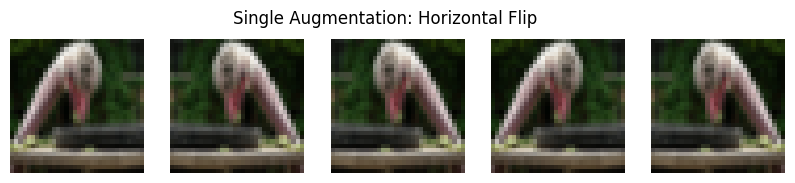

In [ ]:
# Define generator with single augmentation
single_aug = ImageDataGenerator(horizontal_flip=True)

# Show some augmented versions of the same image
sample = x_train[0].reshape((1,32,32,3))
aug_iter = single_aug.flow(sample, batch_size=1)

plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    img = next(aug_iter)[0]
    plt.imshow(img)
    plt.axis('off')
plt.suptitle("Single Augmentation: Horizontal Flip")
plt.show()


## Train With Single Augmentation

In [ ]:
IMG_SIZE = 96

# Resize training and validation data
x_train_resized = tf.image.resize(x_train, (IMG_SIZE, IMG_SIZE))
x_val_resized = tf.image.resize(x_val, (IMG_SIZE, IMG_SIZE))

# Define your augmentation (example: horizontal flip only)
single_aug = ImageDataGenerator(horizontal_flip=True)

# Augmented data generator using resized images
train_gen_single = single_aug.flow(x_train_resized.numpy(), y_train_cat, batch_size=32)

# Build the improved model with pretrained weights
model_single_aug = build_model(img_size=IMG_SIZE)

# Train the model
history_single_aug = model_single_aug.fit(
    train_gen_single,
    epochs=20,
    validation_data=(x_val_resized, y_val_cat),
    steps_per_epoch=len(x_train) // 32,
    verbose=1
)


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 153ms/step - accuracy: 0.2867 - loss: 2.4419 - val_accuracy: 0.6350 - val_loss: 1.1219
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.5649 - loss: 1.2362 - val_accuracy: 0.6500 - val_loss: 0.9284
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6739 - loss: 0.9498 - val_accuracy: 0.7025 - val_loss: 0.8862
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7022 - loss: 0.8297 - val_accuracy: 0.7075 - val_loss: 0.8104
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7514 - loss: 0.7499 - val_accuracy: 0.7075 - val_loss: 0.8398
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7289 - loss: 0.7723 - val_accuracy: 0.7100 - val_loss: 0.7947
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7861 - loss: 0.6408 - val_accuracy: 0.7350 - val_loss: 0.7978
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7903 - loss: 0.5821 - val_accuracy: 0.7150 - val_loss:

## Apply Multiple Augmentations

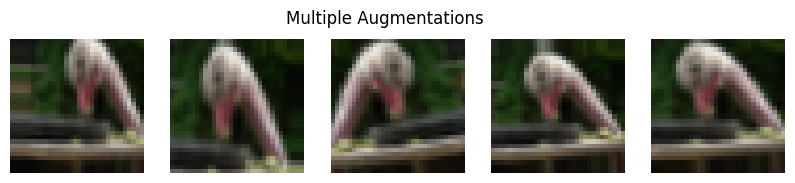

In [ ]:
multi_aug = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2
)

# Show augmented versions of the same image
aug_iter_multi = multi_aug.flow(sample, batch_size=1)
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    img = next(aug_iter_multi)[0]
    plt.imshow(img)
    plt.axis('off')
plt.suptitle("Multiple Augmentations")
plt.show()


## Train With Multiple Augmentations

In [ ]:
IMG_SIZE = 96

# Resize training and validation images
x_train_resized = tf.image.resize(x_train, (IMG_SIZE, IMG_SIZE))
x_val_resized = tf.image.resize(x_val, (IMG_SIZE, IMG_SIZE))

# Define multiple augmentation strategy
multi_aug = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

# Create generator on resized training data
train_gen_multi = multi_aug.flow(x_train_resized.numpy(), y_train_cat, batch_size=32)

# Build  MobileNetV2 model
model_multi_aug = build_model(img_size=IMG_SIZE)

# Train the model
history_multi_aug = model_multi_aug.fit(
    train_gen_multi,
    epochs=20,
    validation_data=(x_val_resized, y_val_cat),
    steps_per_epoch=len(x_train) // 32,
    verbose=1
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 197ms/step - accuracy: 0.2146 - loss: 2.4999 - val_accuracy: 0.6200 - val_loss: 1.2080
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.4734 - loss: 1.4818 - val_accuracy: 0.6550 - val_loss: 0.9966
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.5465 - loss: 1.2756 - val_accuracy: 0.6875 - val_loss: 0.9578
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.6091 - loss: 1.1266 - val_accuracy: 0.7075 - val_loss: 0.8999
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.6104 - loss: 1.1364 - val_accuracy: 0.7000 - val_loss: 0.8564
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.6194 - loss: 1.0831 - val_accuracy: 0.7075 - val_loss: 0.8303
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - accuracy: 0.6433 - loss: 1.0402 - val_accuracy: 0.7075 - val_loss: 0.8272
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.6532 - loss: 1.0145 - val_accuracy: 0.6

## Compare All Results

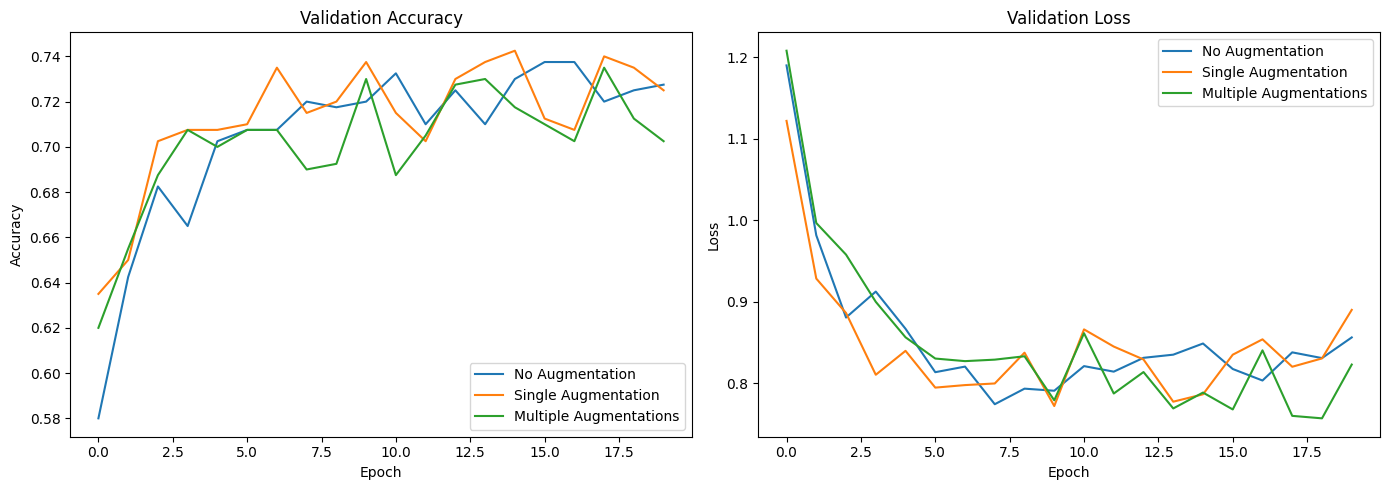

In [ ]:
def plot_val_history(histories, labels):
    plt.figure(figsize=(14,5))

    # Validation Accuracy
    plt.subplot(1,2,1)
    for h, label in zip(histories, labels):
        plt.plot(h.history['val_accuracy'], label=f'{label}')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Validation Loss
    plt.subplot(1,2,2)
    for h, label in zip(histories, labels):
        plt.plot(h.history['val_loss'], label=f'{label}')
    plt.title('Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call the function
plot_val_history(
    [history_no_aug, history_single_aug, history_multi_aug],
    ["No Augmentation", "Single Augmentation", "Multiple Augmentations"]
)
